## Comparison FLR - SIM

In [1]:
# imports
import os
os.environ["GPUBACKENDTOOLS_FORCE_BACKEND"] = "cuda12x"

from fastlisaresponse import ResponseWrapper, pyResponseTDI

from few.waveform import GenerateEMRIWaveform
from few.trajectory.inspiral import EMRIInspiral

from lisatools.detector import Orbits
from lisaconstants import ASTRONOMICAL_YEAR

import matplotlib.pyplot as plt
import numpy as np
import cupy as cp
import pandas as pd
import os
import h5py
from scipy.signal.windows import tukey
from h5py import File
from lisaconstants import ASTRONOMICAL_YEAR
from lisaorbits import OEMOrbits

from scipy.interpolate import CubicSpline

from lisatools.detector import EqualArmlengthOrbits, Orbits
from lisatools.utils.utility import AET

from fastlisaresponse.utils.parallelbase import FastLISAResponseParallelModule
YRSID_SI = ASTRONOMICAL_YEAR
from fastlisaresponse import pyResponseTDI

from multiprocessing.sharedctypes import Value
import numpy as np
from typing import Optional, List
import warnings
from typing import Tuple
from copy import deepcopy

import time
import h5py

/data/leuven/367/vsc36785/miniconda3/envs/lisatools_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [82]:
import few
import lisatools
import fastlisaresponse
import gpubackendtools
print(f'''
few:              {few.__version__}
lisatools:        {lisatools.__version__}
fastlisaresponse: {fastlisaresponse.__version__}
gpubackendtools:  {gpubackendtools.__version__}
''')


few:              2.0.0
lisatools:        1.2.8
fastlisaresponse: 1.2.1a0.post1.dev48+g66fa859db.d20260309
gpubackendtools:  0.1.1



In [3]:
source_index = 6

In [4]:
scratch = '/scratch/leuven/367/vsc36785/MojitoLight/SIM_data/brickmarket/mojito_light_v1_0_0/data/EMRI/L1'

L1_file_path = f'{scratch}/EMRI_731d_2.5s_L1_source6_0_20251203T231104263787Z.h5'

In [5]:
import glob
import os

scratch = '/scratch/leuven/367/vsc36785/MojitoLight/SIM_data/brickmarket/mojito_light_v1_0_0/data/EMRI/L1'
source_index = 6

# Use * as a wildcard for the parts that change
pattern = os.path.join(scratch, f'EMRI_731d_2.5s_L1_source{source_index}_*.h5')
files = glob.glob(pattern)

if files:
    # If multiple versions, sort on stimestamps
    L1_file_path = sorted(files)[-1] 
    print(f"Selected: {L1_file_path}")
else:
    print("No file found for that source index.")

Selected: /scratch/leuven/367/vsc36785/MojitoLight/SIM_data/brickmarket/mojito_light_v1_0_0/data/EMRI/L1/EMRI_731d_2.5s_L1_source6_0_20251203T231104263787Z.h5


In [6]:
from mojito import MojitoL1File    
with MojitoL1File(L1_file_path) as f:

    # Timing parameters
    # l01_t0 = f['tdis/sampling'].attrs['t0']
    # l01_dt = f['tdis/sampling'].attrs['dt']
    # l01_size = f['tdis/sampling'].attrs['size']
    
    tdi_time_sampling = f.tdis.time_sampling
    tdi_dt = tdi_time_sampling.dt
    
    # TDI observables
    CENTRAL_FREQ = f.laser_frequency
    print(CENTRAL_FREQ)
    
    x2 = f.tdis.x2[:] / CENTRAL_FREQ  # TDI X2 observable in Hz
    y2 = f.tdis.y2[:] / CENTRAL_FREQ # TDI Y2 observable in Hz
    z2 = f.tdis.z2[:] / CENTRAL_FREQ # TDI Z2 observable in Hz
    

281600000000000.0


In [7]:
dt = delta_t = tdi_dt
tdi_dt

2.5

In [8]:
x2.shape

(25246480,)

In [9]:
len_waveform = int(x2.shape[0] + 2* (550/dt + 1000))
len_waveform

25248920

The difference in the length of the simulation and the length of the generated waveform: 

In [10]:
25248920 - 25246480

2440

This is the extra part of the waveform that we need to generate: given as a number of samples

In [11]:
2* (550/dt + 1000)

2440.0

In [12]:
Time = len_waveform / ASTRONOMICAL_YEAR *dt

In [13]:
tdi_time_sampling.t0

97729939.827664

In [14]:
def get_mojito_timing(
        oemorbits,
        dt,
        t_dltt_orbits,
        dt_orbits,
        t_strain_offset,
        n_trim_lolipops,
        n_orbit_buffer,
        window_jaxgbresponse,
    ) -> dict:
        """This function derives all timings relevant for Mojito, and generates the
        orbits file and groundtracking file.
        """
        # round up to integer multiple of `dt`
        duration_mojito_light = np.ceil(2.0 * ASTRONOMICAL_YEAR / dt) * dt

        # time reference from orbits file
        orbits = OEMOrbits.from_included(oemorbits)
        t0_orbits = float(orbits.t_start) + t_dltt_orbits

        # sizes: L1 has "+1" to cover full 2-year extent
        size_l1 = int(np.round(duration_mojito_light / dt)) + 1
        size_l0 = size_l1 + 2 * n_trim_lolipops
        size_strain = size_l0 + int(2 * np.ceil(t_strain_offset / dt))
        size_orbits = (
            int(
                np.ceil(((1 + 2 * window_jaxgbresponse) * size_l0 - 1) * dt / dt_orbits)
            )
            + 1
            + 2 * n_orbit_buffer
        )

        # time definitions
        t0_l0 = (
            t0_orbits + n_orbit_buffer * dt_orbits + window_jaxgbresponse * size_l0 * dt
        )
        t_init = t0_l0 - t_strain_offset
        timing_dict = {
            "dt": dt,
            "t_dltt_orbits": t_dltt_orbits,
            "dt_orbits": dt_orbits,
            "t_strain_offset": t_strain_offset,
            "n_trim_lolipops": n_trim_lolipops,
            "n_orbit_buffer": n_orbit_buffer,
            "window_jaxgbresponse": window_jaxgbresponse,
            "t0_orbits": t0_orbits,
            "size_l1": size_l1,
            "size_l0": size_l0,
            "size_strain": size_strain,
            "size_orbits": size_orbits,
            "t0_l0": t0_l0,
            "t_init": t_init,
        }
        return timing_dict

def create_orbits(oemorbits, timing, dense_orbits_path) -> None:
        """Create orbits file"""
        orbits = OEMOrbits.from_included(oemorbits)
        orbits.write(
            dense_orbits_path,    
            dt=timing["dt_orbits"],   
            size=timing["size_orbits"],
            t0=timing["t0_orbits"],
            mode="w",
        )


In [15]:
# create timing dictionary

t_dltt_orbits = 10.
dt_orbits = 5e5
t_strain_offset = 550
n_trim_lolipops = 1000
n_orbit_buffer = 10
window_jaxgbresponse = 0.5 

oemorbits =  "esa-trailing"

In [16]:
dt_orbits

500000.0

In [17]:
timing = get_mojito_timing(
        oemorbits,
        dt,
        t_dltt_orbits,
        dt_orbits,
        t_strain_offset,
        n_trim_lolipops,
        n_orbit_buffer,
        window_jaxgbresponse)

OEM preferred interpolation method ignored, using spline interpolation (see InterpolatedOrbits for details)


In [18]:
timing

{'dt': 2.5,
 't_dltt_orbits': 10.0,
 'dt_orbits': 500000.0,
 't_strain_offset': 550,
 'n_trim_lolipops': 1000,
 'n_orbit_buffer': 10,
 'window_jaxgbresponse': 0.5,
 't0_orbits': 61171239.327664,
 'size_l1': 25246521,
 'size_l0': 25248521,
 'size_strain': 25248961,
 'size_orbits': 274,
 't0_l0': 97731890.577664,
 't_init': 97731340.577664}

In [19]:
# timing
t0_l1 = tdi_time_sampling.t0
t0_l0 = t0_l1 - 1000*dt
t_init = t0_l0 - 550 

In [20]:
print(f'''
t0_l1 = {t0_l1}
t0_l0 = {t0_l0}
t_init = {t_init}
''')


t0_l1 = 97729939.827664
t0_l0 = 97727439.827664
t_init = 97726889.827664



## Build waveform object
Set up the waveform object with right keywords

In [21]:
from fastlisaresponse.utils.parallelbase import ParallelModuleBase
# Create EMRIWave object
sum_kwargs = {
    "pad_output": True,
}

inspiral_kwargs = {
    "DENSE_STEPPING": 0,  # sparsely sampled trajectory
    "max_init_len": int(1e8),  # length of trajectories well under 1000
}

amplitude_kwargs = {
    # "max_init_len": int(1e8),  # all of the trajectories will be well under len = 1000
    # "use_gpu": True,
    # "file_dir":"/data/leuven/367/vsc36785/LISA/FastEMRIWaveforms/data"
}

waveform_kwargs = {
    'mode_selection_threshold': 0.0
}

In [22]:
class EMRIWave_base(ParallelModuleBase):
    def __init__(self, force_backend=None, 
                use_gpu=True, 
                 inspiral_kwargs=inspiral_kwargs,
                 sum_kwargs=sum_kwargs,
                 amplitude_kwargs=amplitude_kwargs,
                 mode_selection_threshold=1e-5,
                 t_init=33568152.5,
                 t0_orbits=33568152.5,
                 dt=5, 
                 n_samples=1000,
                 offset=550, # seconds
                 strain_only=False,
                 time=2.0
                ):
                 
        super().__init__(force_backend=force_backend)
        
        self.use_gpu = use_gpu
        self.mode_threshold = mode_selection_threshold
        
        # Initialize waveform generator

        self.waveform_gen = GenerateEMRIWaveform(
                "FastKerrEccentricEquatorialFlux",
                return_list=False,    # returns hp - i*hx as a complex cupy array
                inspiral_kwargs=inspiral_kwargs,
                sum_kwargs=sum_kwargs,
                amplitude_kwargs=amplitude_kwargs,
                frame="detector"
            )
        self.t_init = t_init
        self.t0_orbits = t0_orbits
    
    @classmethod
    def supported_backends(cls):
        return ["fastlisaresponse_" + _tmp for _tmp in cls.GPU_RECOMMENDED()]

    def __call__(self, *params, T=2, dt=5):
        '''
        Call FEW waveform model and return the strain as h_+ - ih_x
        '''
        # define correct time grid for waveform generation.
        waveform_kwargs['T'] = T
        waveform_kwargs['dt'] = dt
        waveform_kwargs['mode_selection_threshold'] = self.mode_threshold
        strain = self.waveform_gen(*params, **waveform_kwargs)

        return strain

In [23]:
orbits = OEMOrbits.from_included(oemorbits)
t0_orbits = float(orbits.t_start) + t_dltt_orbits

n_samples = 1000 # necessary to do the TDI delays

use_gpu=True
t_smooth=0
waveform_model='Kerr'
mode_selection_threshold = 0.0

f_s = 1/dt   
home_folder = os.getcwd()

OEM preferred interpolation method ignored, using spline interpolation (see InterpolatedOrbits for details)


In [24]:
emri_waveform = EMRIWave_base(use_gpu=use_gpu, 
                         mode_selection_threshold=mode_selection_threshold,
                         strain_only=False,
                         t0_orbits=t0_orbits,
                         t_init=t_init,
                         dt=dt, 
                         n_samples=n_samples,
                         offset=550, # seconds
                        )

## Get source parameters
get the source parameters from the catalog

In [25]:
from mojito.download import get_source_params

# Get source parameters for mbhb brick, source ID 12
params = get_source_params("emri", source_id=source_index, username='bert-depoorter', token='2c7#QBB9DTh8QgJPpw')

WARNING! Publications using Mojito data are currently not allowed! Please keep in touch, as publication policies will soon be published.


In [26]:
params

{'AzimuthalAnglePrimarySpin': np.float64(3.849520179081373),
 'AzimuthalPhase': np.float64(3.1939745793887977),
 'ChirpMassSSBFrame': np.float64(3364.153490238571),
 'Declination': np.float64(0.7313689457484064),
 'Eccentricity': np.float64(0.7439559287139789),
 'EstimatedSNR': np.float64(95.84905866519384),
 'ID': np.int64(7),
 'InclinationAngle': np.float64(0.0),
 'LuminosityDistance': np.float64(4755.290534781199),
 'MassRatio': np.float64(0.000146453721146835),
 'PolarAnglePrimarySpin': np.float64(1.1706519351964189),
 'PolarPhase': np.float64(3.3779647386796587),
 'PrimaryMassSSBFrame': np.float64(672153.2079661994),
 'PrimaryMassSourceFrame': np.float64(382296.2157652893),
 'PrimarySpinParameter': np.float64(0.5),
 'RadialPhase': np.float64(0.6038015447102911),
 'Redshift': np.float64(0.7582000036821386),
 'RightAscension': np.float64(3.9684956565955574),
 'SecondaryMassSSBFrame': np.float64(98.43933848743235),
 'SecondaryMassSourceFrame': np.float64(55.98870337917995),
 'SemiLat

In [27]:
def icrs_to_ecliptic(ra, dec):
    """Convert ICRS coordinates (ra, dec) to ecliptic coordinates (lambda, beta)."""
    from astropy.coordinates import SkyCoord
    import astropy.units as u

    icrs_coord = SkyCoord(ra=ra * u.rad, dec=dec * u.rad, frame='icrs')
    ecliptic_coord = icrs_coord.barycentrictrueecliptic

    lambda_ecl = ecliptic_coord.lon.rad
    beta_ecl = ecliptic_coord.lat.rad

    return lambda_ecl, beta_ecl

In [28]:
ra = params['RightAscension']
dec = params['Declination']

lam_ecl, beta_ecl = icrs_to_ecliptic(ra, dec)
qS_ecl = np.pi / 2 - beta_ecl
phiS_ecl = lam_ecl


In [29]:
# extract source parameters
params_mojito = [
    params['PrimaryMassSSBFrame'],
    params['SecondaryMassSSBFrame'],
    params['PrimarySpinParameter'],
    params['SemiLatusRectum'],
    params['Eccentricity'],
    np.cos(params['InclinationAngle']),
    params['LuminosityDistance']*1e-3,
    qS_ecl,  # np.pi/2 - beta
    phiS_ecl,  # lambda
    params['PolarAnglePrimarySpin'],
    params['AzimuthalAnglePrimarySpin'],
    params['AzimuthalPhase'],
    params['PolarPhase'],
    params['RadialPhase'],
]

### test waveform module

In [30]:
emri_test = emri_waveform(*params_mojito, T = 2, dt=dt)

(36900450.53134839, 36902664.66908716)

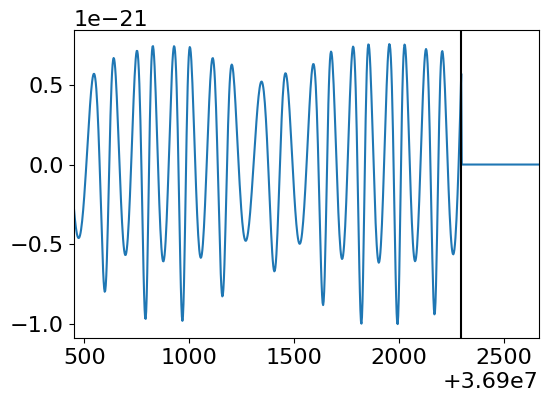

In [31]:
time = np.arange(len(emri_test)) * dt

fig, ax = plt.subplots(1,1, figsize=(6,4))
ax.plot(time, emri_test.real.get())
ax.axvline(params['TimeCoalescenceSSBFrame'], color='black')

ax.set_xlim([0.99995* params['TimeCoalescenceSSBFrame'], 1.00001*params['TimeCoalescenceSSBFrame']])

In [32]:
orbit_file= f'{home_folder}/esa-trailing-orbits-mojito_validation_test_2.h5'
force_backend = 'cuda12x'
esa = Orbits(filename=orbit_file, 
            use_gpu=use_gpu, 
            force_backend=force_backend, 
            linear_interp_setup=False,
            t0=t0_orbits)

In [33]:
len(params_mojito)

14

In [34]:
force_backend = "cuda12x" if use_gpu else None

index_beta = 7
index_lambda = 8

tdi_kwargs = {
    'tdi': '2nd generation',
    'tdi_chan': 'XYZ',
    'order': 39,
}

In [35]:
from fastlisaresponse.tdiconfig import TDIConfig
tdi_kwargs_esa = dict(
            orbits=esa,
            order=40,
            tdi=TDIConfig('2nd generation'),
            tdi_chan="XYZ",
        )

In [36]:
Tobs = 2 # years
offset = 550
n_samples = 1000
T = Tobs + (2* offset + 2*n_samples*dt)/ASTRONOMICAL_YEAR


In [37]:
emri_TDI_list = ResponseWrapper(
    emri_waveform,
    T,
    dt,
    index_lambda,
    index_beta,
    t0=t_init,
    t_buffer = 10000.0,
    flip_hx=True,  # set to True if waveform is h+ - ihx
    force_backend=force_backend,
    remove_sky_coords=False,  # True if the waveform generator does not take sky coordinates
    is_ecliptic_latitude=False,  # False if using polar angle (theta)
    remove_garbage=False,  # removes the beginning of the signal that has bad information
    # orbits=esa,
    **tdi_kwargs_esa,
)

In [38]:
def emri_TDI(*params):
    return cp.asarray(emri_TDI_list(*params))

In [39]:
chans = emri_TDI(*params_mojito)

In [40]:
time = np.arange(len(chans[0])) * dt / YRSID_SI

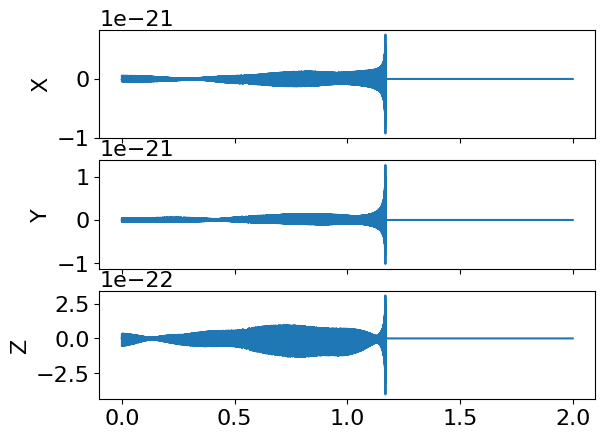

In [41]:
fig, ax = plt.subplots(3, 1, sharex=True)

for i, lab in enumerate(["X", "Y", "Z"]):
    ax[i].plot(time[::10], chans[i].get()[::10])
    # ax[i].set_xlim([1.999, 2.001])
    ax[i].set_ylabel(lab)

In [42]:
chans.shape

(3, 25248959)

In [43]:
x2.shape

(25246480,)

In [44]:
25248959 - 25246480

2479

In [45]:
850.5 / dt

340.2

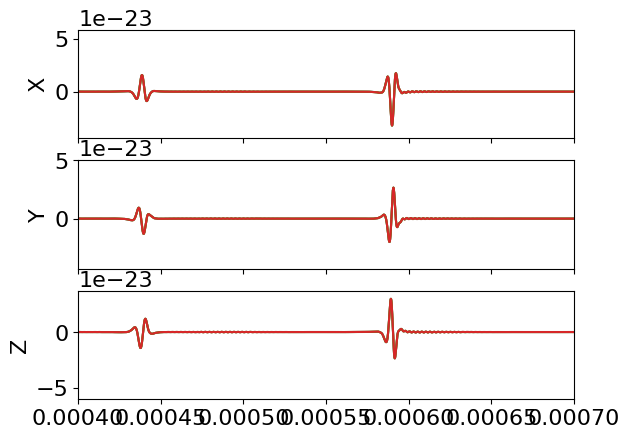

In [46]:
fig, ax = plt.subplots(3, 1, sharex=True)

for i, lab in enumerate(["X", "Y", "Z"]):
    ax[i].plot(time[:10000], chans[i].get()[:10000])
    ax[0].plot(time[:10000]+850.5/ASTRONOMICAL_YEAR, x2[:10000])
    ax[1].plot(time[:10000]+850.5/ASTRONOMICAL_YEAR, y2[:10000])
    ax[2].plot(time[:10000]+850.5/ASTRONOMICAL_YEAR, z2[:10000])
    ax[i].set_xlim([0.0004, 0.0007])
    ax[i].set_ylabel(lab)

## Comparison plots

In [47]:
dt

2.5

In [48]:
time_sim_L1 = np.arange(t_init + 850.5, x2.shape[0]*delta_t + t_init + 850.5, dt)[:-1]  
time_flr_L1 = np.arange(t_init, chans.shape[1]*delta_t + t_init, dt)[:-1] 

In [49]:
len(chans[0])

25248959

In [50]:
time_flr_L1.shape

(25248959,)

Text(0.5, 1.0, 'TDI X channel')

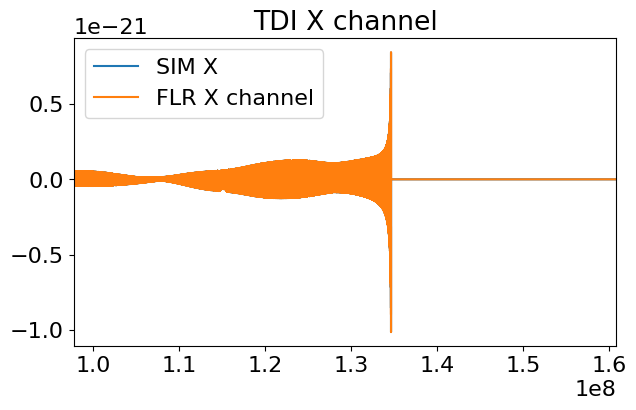

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))


ax.plot(time_sim_L1, x2, label='SIM X')   
ax.plot(time_flr_L1, chans[0].get(), label='FLR X channel')
ax.set_xlim([time_sim_L1[0], time_sim_L1[-1]])
ax.legend(loc='upper left')
ax.set_title('TDI X channel')

Text(0.5, 1.0, 'TDI Y channel')

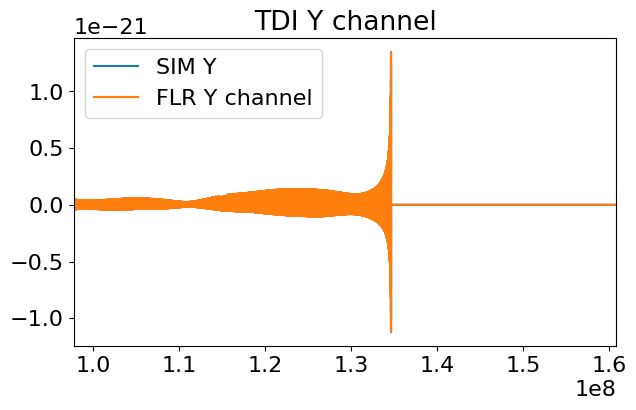

In [52]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))


ax.plot(time_sim_L1, y2, label='SIM Y')   
ax.plot(time_flr_L1, chans[1].get(), label='FLR Y channel')
ax.set_xlim([time_sim_L1[0], time_sim_L1[-1]])
ax.legend(loc='upper left')
ax.set_title('TDI Y channel')

Text(0.5, 1.0, 'TDI Z channel')

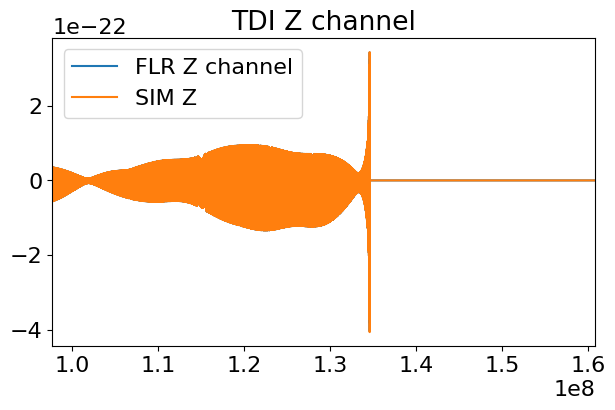

In [53]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))

ax.plot(time_flr_L1, chans[2].get(), label='FLR Z channel')
ax.plot(time_sim_L1, z2, label='SIM Z')   
# ax.plot(time_flr_L1, chans[2].get(), label='FLR Z channel')
ax.set_xlim([time_sim_L1[0], time_sim_L1[-1]])
ax.legend(loc='upper left')
ax.set_title('TDI Z channel')

In [54]:
T_plunge = params['TimeCoalescenceSSBFrame'] + t_init - 50.5

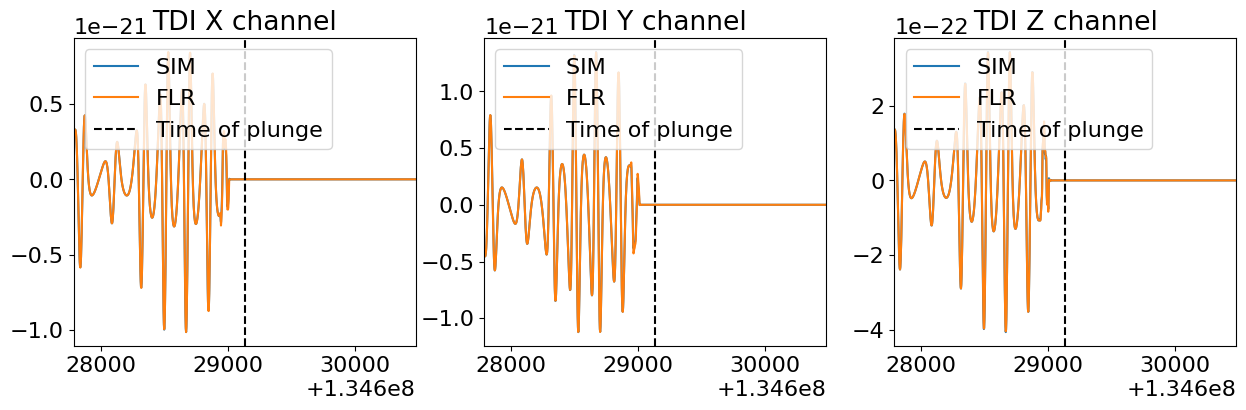

In [55]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
labels = ['X', 'Y', 'Z']
sim_data = {0: x2, 1: y2, 2: z2}

for i, lab in enumerate(labels):
    ax[i].plot(time_sim_L1, sim_data[i], label=f'SIM ')   
    ax[i].plot(time_flr_L1, chans[i].get(), label=f'FLR')
    ax[i].set_xlim([0.99999 * T_plunge, 1.00001 * T_plunge])
    ax[i].axvline(T_plunge, linestyle='--', color='black', label='Time of plunge')
    ax[i].legend(loc='upper left')
    
    ax[i].set_title(f'TDI {lab} channel')

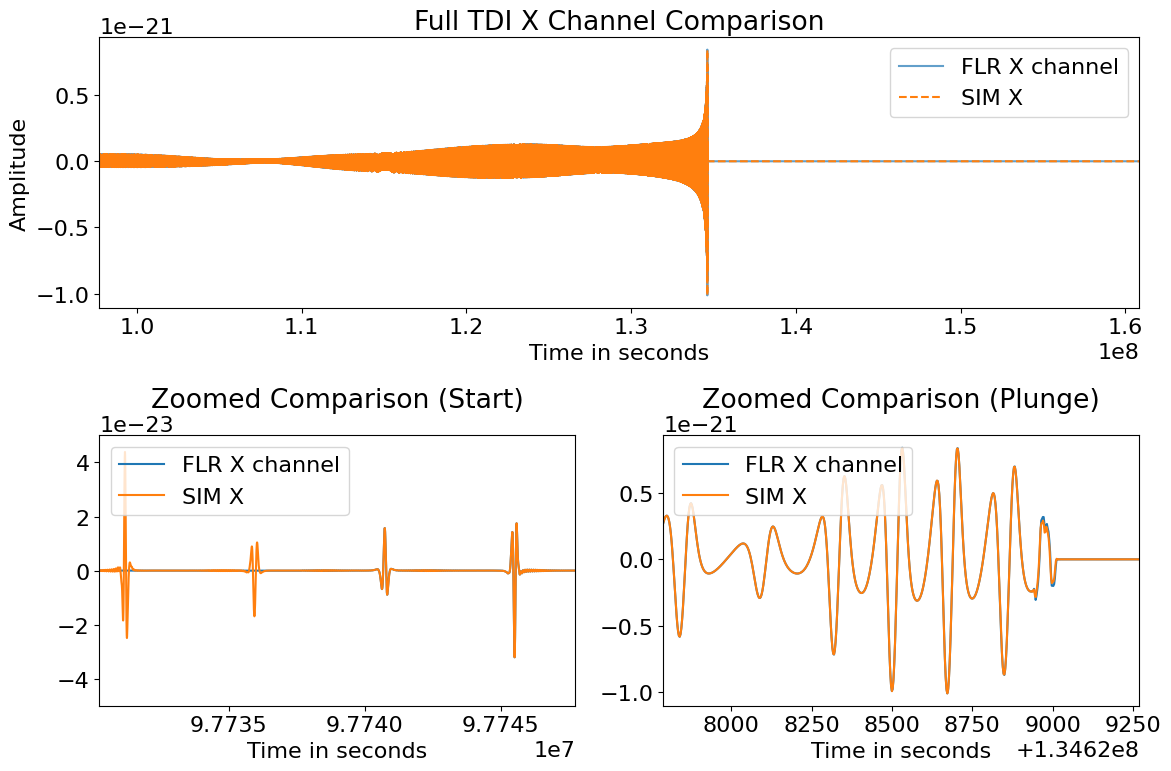

In [56]:
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(2, 2)

# panel with full thing
ax_top = fig.add_subplot(gs[0, :]) # Spans row 0, all columns
ax_top.plot(time_flr_L1, chans[0].get(), label='FLR X channel', alpha=0.7)
ax_top.plot(time_sim_L1, x2, label='SIM X', linestyle='--')
ax_top.set_xlim([time_sim_L1[0], time_sim_L1[-1]])
ax_top.set_title('Full TDI X Channel Comparison')
ax_top.legend(loc='upper right')
ax_top.set_xlabel('Time in seconds')
ax_top.set_ylabel('Amplitude')

# bottom left
ax_left = fig.add_subplot(gs[1, 0])
ax_left.plot(time_flr_L1, chans[0].get(), label='FLR X channel')
ax_left.plot(time_sim_L1, x2, label='SIM X')   
ax_left.set_xlim([(time_sim_L1[0])+1000*dt, (time_sim_L1[0]+ 0.00005)+8000*dt])
ax_left.set_ylim([-5e-23, 5e-23])
ax_left.legend(loc='upper left')
ax_left.set_xlabel('Time in seconds')
ax_left.set_title('Zoomed Comparison (Start)')

# Bottom right
ax_right = fig.add_subplot(gs[1, 1])
ax_right.plot(time_flr_L1, chans[0].get(), label='FLR X channel')
ax_right.plot(time_sim_L1, x2, label='SIM X')   
ax_right.set_xlim([0.99999*T_plunge, 1.000001*T_plunge])
# ax_right.set_xlim([(4.26612)*YRSID_SI/dt, (4.26615)*YRSID_SI/dt])
ax_right.legend(loc='upper left')
ax_right.set_xlabel('Time in seconds')
ax_right.set_title('Zoomed Comparison (Plunge)')

plt.tight_layout()
plt.show()

### Mismatch and SNR computations

In [57]:
from lisatools.datacontainer import DataResidualArray
from lisatools.analysiscontainer import AnalysisContainer
from lisatools.sensitivity import SensitivityMatrix

from lisatools.domains import TDSettings, FDSettings, FDSignal, TDSignal

In [58]:
chans.shape

(3, 25248959)

In [59]:
tdi_channels_here = np.array([tdi_channel.get() for tdi_channel in chans])

In [60]:
# now spline interpolate the tdi channels to the same time array as the data
from scipy.interpolate import CubicSpline
window = tukey(len(time_sim_L1), alpha=0.01)

xyz_splined = np.array([
    CubicSpline(time_flr_L1, chan)(time_sim_L1) for chan in tdi_channels_here
])

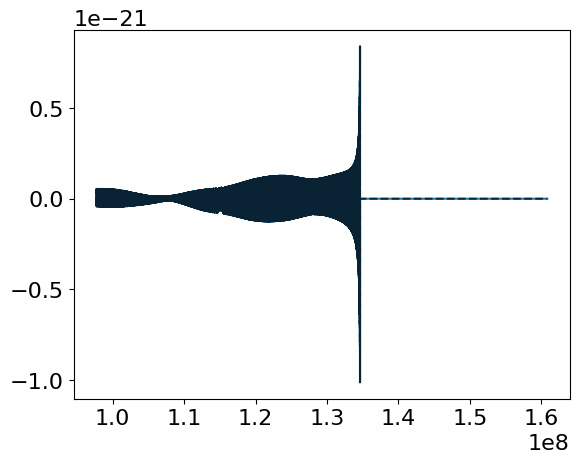

In [61]:
NPLOT = int(1e9)

plt.plot(time_sim_L1[:NPLOT], x2[:NPLOT], label='L1 X')
plt.plot(time_sim_L1[:NPLOT], xyz_splined[0][:NPLOT], alpha=0.7, label='EMRI waveform X', c='k', ls='--')


In [62]:
data = cp.asarray([x2, y2, z2])

In [63]:
xyz_residual = data - cp.asarray(xyz_splined)

In [64]:
window.shape

(25246480,)

In [65]:
xyz_residual_windowed = xyz_residual * cp.asarray(window)
xyz_residual_windowed.shape

(3, 25246480)

In [66]:
# window signal
xyz_residual_windowed = xyz_residual * cp.asarray(window)
xyz_data_windowed = data * cp.asarray(window)
xyz_splined_windowed = cp.asarray(xyz_splined) * cp.asarray(window)

# apply fft
xyz_residual_fft = cp.fft.rfft(xyz_residual_windowed, axis=1)
xyz_data_fft = cp.fft.rfft(xyz_data_windowed, axis=1)
xyz_splined_fft = cp.fft.rfft(xyz_splined_windowed, axis=1)


N_t = len(data[0])
freqs = cp.fft.rfftfreq(N_t, d=dt)

f_max = 1/(2*dt) # Nyquist frequency
f_min = 1e-5 # minimum frequency to consider
mask = (freqs >= f_min) & (freqs <= f_max)
freqs_inband = freqs[mask]

# filter frequencies
xyz_data_fft_inband = xyz_data_fft[:, mask]
xyz_splined_fft_inband = xyz_splined_fft[:, mask]
xyz_residual_fft_inband = xyz_residual_fft[:, mask]


In [67]:
xyz_residual_fft_inband.shape

(3, 12622609)

In [68]:
freqs_inband.shape

(12622609,)

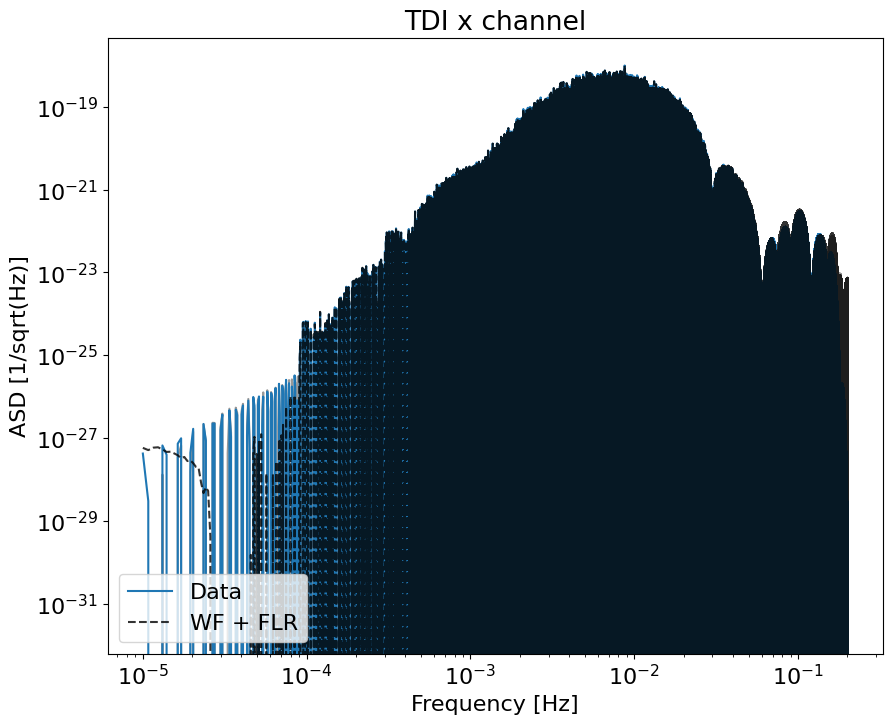

In [75]:
# make plot

fig, axs = plt.subplots(1, 1, figsize=(10, 8))

channels = ['TDI x', 'TDI Y', 'TDI Z']
i = 0

DecimFactor = 50
axs.loglog(freqs_inband[::DecimFactor].get(), xyz_data_fft_inband[i, ::DecimFactor].get(), label='Data')
axs.loglog(freqs_inband[::DecimFactor].get(), xyz_splined_fft_inband[i, ::DecimFactor].get(), label='WF + FLR', c='k', ls='--', alpha=0.8)
axs.loglog(freqs_inband[::DecimFactor].get(), xyz_residual_fft_inband[i, ::DecimFactor].get(), c='gray', alpha=0.8, zorder=0)

axs.set_title(f"{channels[i]} channel")
axs.legend(loc='lower left')

axs.set_xlabel("Frequency [Hz]")
axs.set_ylabel("ASD [1/sqrt(Hz)]")


# plt.ylim(1e-26, 1e-17)

plt.show()
#plt.xlim(1e-5, 0.2)

In [72]:
# load noise estimates
CENTRAL_FREQ = 281600000000000.0
noise_file = os.path.join(path, "data/INSTRUMENT/L1/NOISE_731d_2.5s_L1_source0_0_20251206T220508924302Z.h5")

with h5py.File(noise_file, "r") as f:
    xyz_noise_estimate = np.mean(f['noise_estimates/XYZ'][:], axis=0) / CENTRAL_FREQ**2
    fmin_noise_psd = f['noise_estimates/log_frequency_sampling'].attrs['fmin']
    fmax_noise_psd = f['noise_estimates/log_frequency_sampling'].attrs['fmax']
    size_noise_psd = f['noise_estimates/log_frequency_sampling'].attrs['size']

    noise_freqs = np.logspace(np.log10(fmin_noise_psd), np.log10(fmax_noise_psd), size_noise_psd)

In [ ]:
12623241

In [86]:
times_waveform = time_sim_L1.copy()

wf_td_settings = TDSettings(
    # t0=times_waveform[0],
    dt=dt,
    N=len(times_waveform),
    force_backend='cuda12x'
)

fd_settings = FDSettings(
    # min_freq=1e-5,
    # max_freq=0.2,
    df= 1 / (wf_td_settings.N * wf_td_settings.dt),
    N= wf_td_settings.N // 2 + 1,
    force_backend='cuda12x'
)

In [87]:
xyz_splined.shape

(3, 25246480)

In [88]:
data.shape

(3, 25246480)

In [89]:
from scipy.signal.windows import tukey

alpha = 0.01

window = cp.asarray(tukey(wf_td_settings.N, alpha=alpha))

In [90]:
TDSignal(arr=xyz_splined, settings=wf_td_settings).xp

<module 'cupy' from '/data/leuven/367/vsc36785/miniconda3/envs/lisatools_env/lib/python3.14/site-packages/cupy/__init__.py'>

In [91]:
fd_settings.xp

<module 'cupy' from '/data/leuven/367/vsc36785/miniconda3/envs/lisatools_env/lib/python3.14/site-packages/cupy/__init__.py'>

In [92]:
wf_td_settings.xp

<module 'cupy' from '/data/leuven/367/vsc36785/miniconda3/envs/lisatools_env/lib/python3.14/site-packages/cupy/__init__.py'>

In [93]:
from cupy import get_array_module
get_array_module(cp.asarray(xyz_splined))

<module 'cupy' from '/data/leuven/367/vsc36785/miniconda3/envs/lisatools_env/lib/python3.14/site-packages/cupy/__init__.py'>

In [94]:
xyz_splined_cp = cp.asarray(xyz_splined)

In [95]:
TDSignal(arr=xyz_splined_cp, settings=wf_td_settings)

In [96]:
wf_res_arr = DataResidualArray(
    data_res_in=TDSignal(arr=cp.asarray(xyz_splined_cp), settings=wf_td_settings),
    signal_domain=fd_settings,
    input_signal_domain=wf_td_settings,
    window=cp.asarray(window),
    force_backend='cuda12x'
)

TypeError: Unsupported type <class 'numpy.ndarray'>

In [83]:
data_res_arr = DataResidualArray(
    data_res_in=TDSignal(arr=data, settings=wf_td_settings),
    signal_domain=fd_settings,
    window=window
)

residuals_res_arr = DataResidualArray(
    data_res_in=TDSignal(arr=xyz_residual, settings=wf_td_settings),
    signal_domain=fd_settings,
    window=window
)

TypeError: Unsupported type <class 'numpy.ndarray'>

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(25, 8), sharex=True, sharey=True)

axs = list(axs)

data_res_arr.loglog(fig=fig, ax=axs, label='Data')
wf_res_arr.loglog(fig=fig, ax=axs, label='WF + FLR', c='k', ls='--', alpha=0.8)
residuals_res_arr.loglog(fig=fig, ax=axs, c='gray', alpha=0.8, zorder=0)

# add noise estimates

for i in range(3):
    axs[i].loglog(noise_freqs, xyz_noise_estimate[:, i, i] ** 0.5, c='red', ls=':')

axs[0].set_title("X channel")
axs[1].set_title("Y channel")
axs[2].set_title("Z channel")

axs[0].set_xlabel("Frequency [Hz]")
axs[0].set_ylabel("ASD [1/sqrt(Hz)]")

plt.legend(loc='lower left')
plt.ylim(1e-26, 1e-17)

plt.show()
#plt.xlim(1e-5, 0.2)

In [ ]:
freqs = wf_res_arr.settings.f_arr

In [ ]:
# now compute the covariance matrix at these frequencies

splined_noise_psd = np.array([
    CubicSpline(noise_freqs, xyz_noise_estimate[:, i, i])(freqs) for i in range(3)
])

splined_noise_csd_real = np.array([
    CubicSpline(noise_freqs, xyz_noise_estimate[:, i, j].real)(freqs) for i in range(3) for j in range(i, 3)
])

splined_noise_psd_imag = np.array([
    CubicSpline(noise_freqs, xyz_noise_estimate[:, i, j].imag)(freqs) for i in range(3) for j in range(i, 3)   
])

In [ ]:
# now re-assemble the covariance matrix
covariance_matrices = np.zeros((3, 3, len(freqs)), dtype=complex)
for i in range(3):
    covariance_matrices[i, i, :] = splined_noise_psd[i]
    for j in range(i+1, 3):
        covariance_matrices[i, j, :] = splined_noise_csd_real[i*3 + j - (i+1)*i//2] + 1j * splined_noise_psd_imag[i*3 + j - (i+1)*i//2]
        covariance_matrices[j, i, :] = np.conj(covariance_matrices[i, j, :])

In [50]:
t0_orbits

61171239.327664

In [49]:
params['TimeCoalescenceSSBFrame']

np.float64(57519947.48327901)

In [ ]:
57519947.48327901
61171239.327664

In [50]:
t0_l0+322.5

97730262.327664

### Quantitative comparison